# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 11 </span>
## <span style="color:orange"> Keras - Neural Network regression </span>

### Overview 

In this notebook our task will be to perform machine learning regression on noisy data with a Neural Network (NN).

We will explore how the ability to fit depends on the structure of the NN. The goal is also to build intuition about why prediction is difficult.

### The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data. 

To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

We will try to get a qualitative picture by examining plots on validation and training data.

### Linear fit

We start by considering the very simple case:
$$
f(x)=2x+1
$$

Let's start defining the parameters of an ideal linear function which we are going to predict through a neural network regression

In [55]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

Now let's generate a set of input data which will slightly deviate from our ideal behaviour using a random noise (that actually is set to zero):

In [56]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 500)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

sigma = 0.0 # noise standard deviation, for the moment it is absent
y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

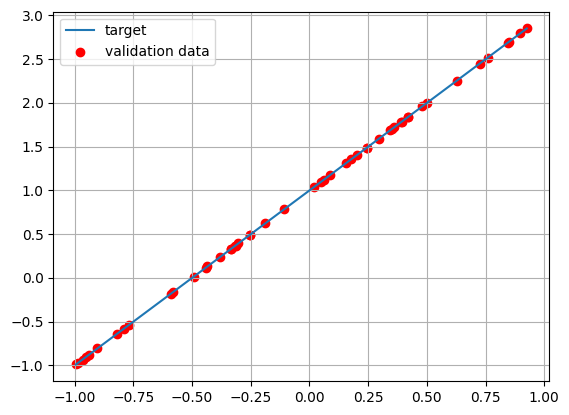

In [57]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

If you remember how a single node of a neural network works, you can easily spot that **just a single neuron can make the job**. So let's start using a simple Sequential model with just one layer on one neuron only!

In [58]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Dense(1, input_shape=(1,))) 

# compile the model choosing 
# - optimizer = stochastic gradient descent
# - mean squared error (cost function)
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

/Users/carlagariboldi/Documents/MARTINO/UNIMI/III anno/Labo_SimulazioneNumerica/es_11/tf-env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
# get a summary of our composed model
model.summary()

Model: "sequential_528"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1464 (Dense)              │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

We are now going to train our model, that is we feed the neuron with the set of training pair x, y_train from which the optimizer will find the best weights to minimize the Mean Square Error loss function (out linear regression function).

In [60]:
"""
Training arguments explanation:
- x, y: Provides the input data and target labels for the model to learn from.
- batch_size: The model processes 32 samples at a time, calculates the error, and updates the weights.
- epochs: One complete pass over the entire training dataset. The process is repeated 30 times.
- shuffle: Randomly shuffles the data before each epoch to prevent the model from memorizing the sequence.
- validation_data: Evaluates the model on unseen data at the end of each epoch to check for generalization and monitor overfitting.
"""
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=30,
          shuffle=True,
          validation_data=(x_valid, y_valid))

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3419 - mse: 1.3419 - val_loss: 0.9316 - val_mse: 0.9316
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8732 - mse: 0.8732 - val_loss: 0.6193 - val_mse: 0.6193
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5945 - mse: 0.5945 - val_loss: 0.4304 - val_mse: 0.4304
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4205 - mse: 0.4205 - val_loss: 0.3116 - val_mse: 0.3116
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3081 - mse: 0.3081 - val_loss: 0.2346 - val_mse: 0.2346
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2332 - mse: 0.2332 - val_loss: 0.1800 - val_mse: 0.1800
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1793 - mse: 0.1793 - val_loss: 0.1403 - val_mse: 0.1403
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1397 - mse: 0.1397 - val_loss: 0.1109 - val_mse: 0.1109
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1102 - mse: 

By looking at weights and biases we can see if the linear fit was successfull: $w_1$ represents the angular coefficient, $b$ the intercept.

In [61]:
# return weights and biases
model.get_weights()

[array([[1.9469107]], dtype=float32), array([0.99933016], dtype=float32)]

In [62]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.9580e-04 - mse: 8.9580e-04

Test loss: 0.0008957994868978858
Test accuracy: 0.0008957994868978858


In [63]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.9580e-04 - mse: 8.9580e-04

Test loss: 0.0008957994868978858
Test accuracy: 0.0008957994868978858


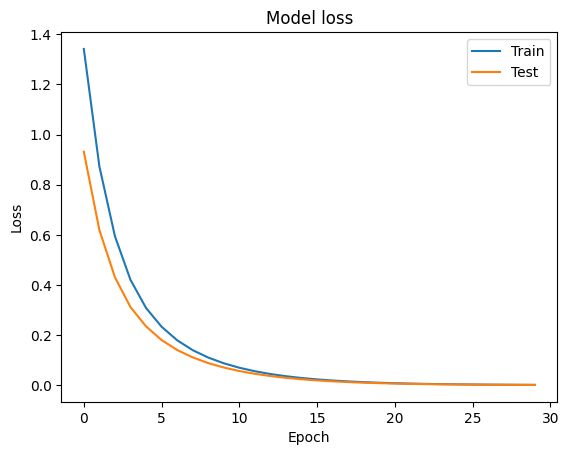

In [64]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

In [65]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r')
plt.plot(x_valid, y_target)
plt.grid(True)
plt.show()

KeyboardInterrupt: 

### Exercise 11.1

In order to make practice with NN, explore how does the previous linear regression depend on the number of epochs, $N_{\mathrm{epochs}}$, the number of data points $N_{\mathrm{train}}$ and on the noise $\sigma$. Try to improve the previous result operating on these parameters.

### Exercise 11.2

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Find good (& reasonable) choices for:

- the number of layers
- the number of neurons in each layer
- the activation function
- the optimizer
- the loss function
  
Check your NN model by seeing how well your fits predict newly generated test data (including on data outside the range you fit. How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set? 
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.

### Exercise 11.3
  
Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.

Ideas to meditate on these exercises and judge your results can be found <a href=https://xkcd.com/2048/>here</a>

## **Submission**

### **Supervised Neural Networks**
The three main elements necessary to define a NN are:
- the dataset $D = (X, Y)$ where X and Y are a set of respectively independent and dependent variables. 
- function $f(X,p)$ $f:x\to y$ with a series of parameters p, it is used to predict an output starting from the input variables $X$. 
- the final element necessary is the cost function $C[y, f(X,p)]$ that allows us undestand how well the model is doing with respect to the observations. The model happens to be well determined by finding the values of $p$ that minimize the cost function for all values of $X$. 

To train the model we divide the majority of the dataset in training data and use it to determine $p$, we verify that $p$ is in fact the set of parameters that minimizes the cost function by evaluating $E_{out} := C[Y_{test}; f(X_{test}, p)]$. It is possible to compare $E_{in} :=C[Y_{train}; f(X_{train}, p)$ with $E_{out}$, and generally $E_{in} \leq E_{out}$ because test data contains new information not used in the training set, while the NN has trained itself to the training data. 

### **Exercise 11.1**

In order to make practice with NN, explore how does the linear regression of the function $f(x)$ depend on the number of epochs, $N_{\mathrm{epochs}}$, the number of data points $N_{\mathrm{train}}$ and on the noise $\sigma$. Try to improve the previous result operating on these parameters.
$$f(x) = 2x + 1$$

In this case for every neuron I have two parameters that I can vary so that if I have $N$ neurons, there are $2N$ training parameters. In this case we want to fit a function dependent only on two parameters, thus only one neuron is necessary to do so.

--- Model with sigma = 0.1 ---
Test loss (vs validation): 0.0486
Test loss (vs target exact): 0.0406

--- Model with sigma = 0.2 ---
Test loss (vs validation): 0.1016
Test loss (vs target exact): 0.0624

--- Model with sigma = 0.4 ---
Test loss (vs validation): 0.3072
Test loss (vs target exact): 0.0842

--- Model with sigma = 0.6 ---
Test loss (vs validation): 0.4420
Test loss (vs target exact): 0.0148



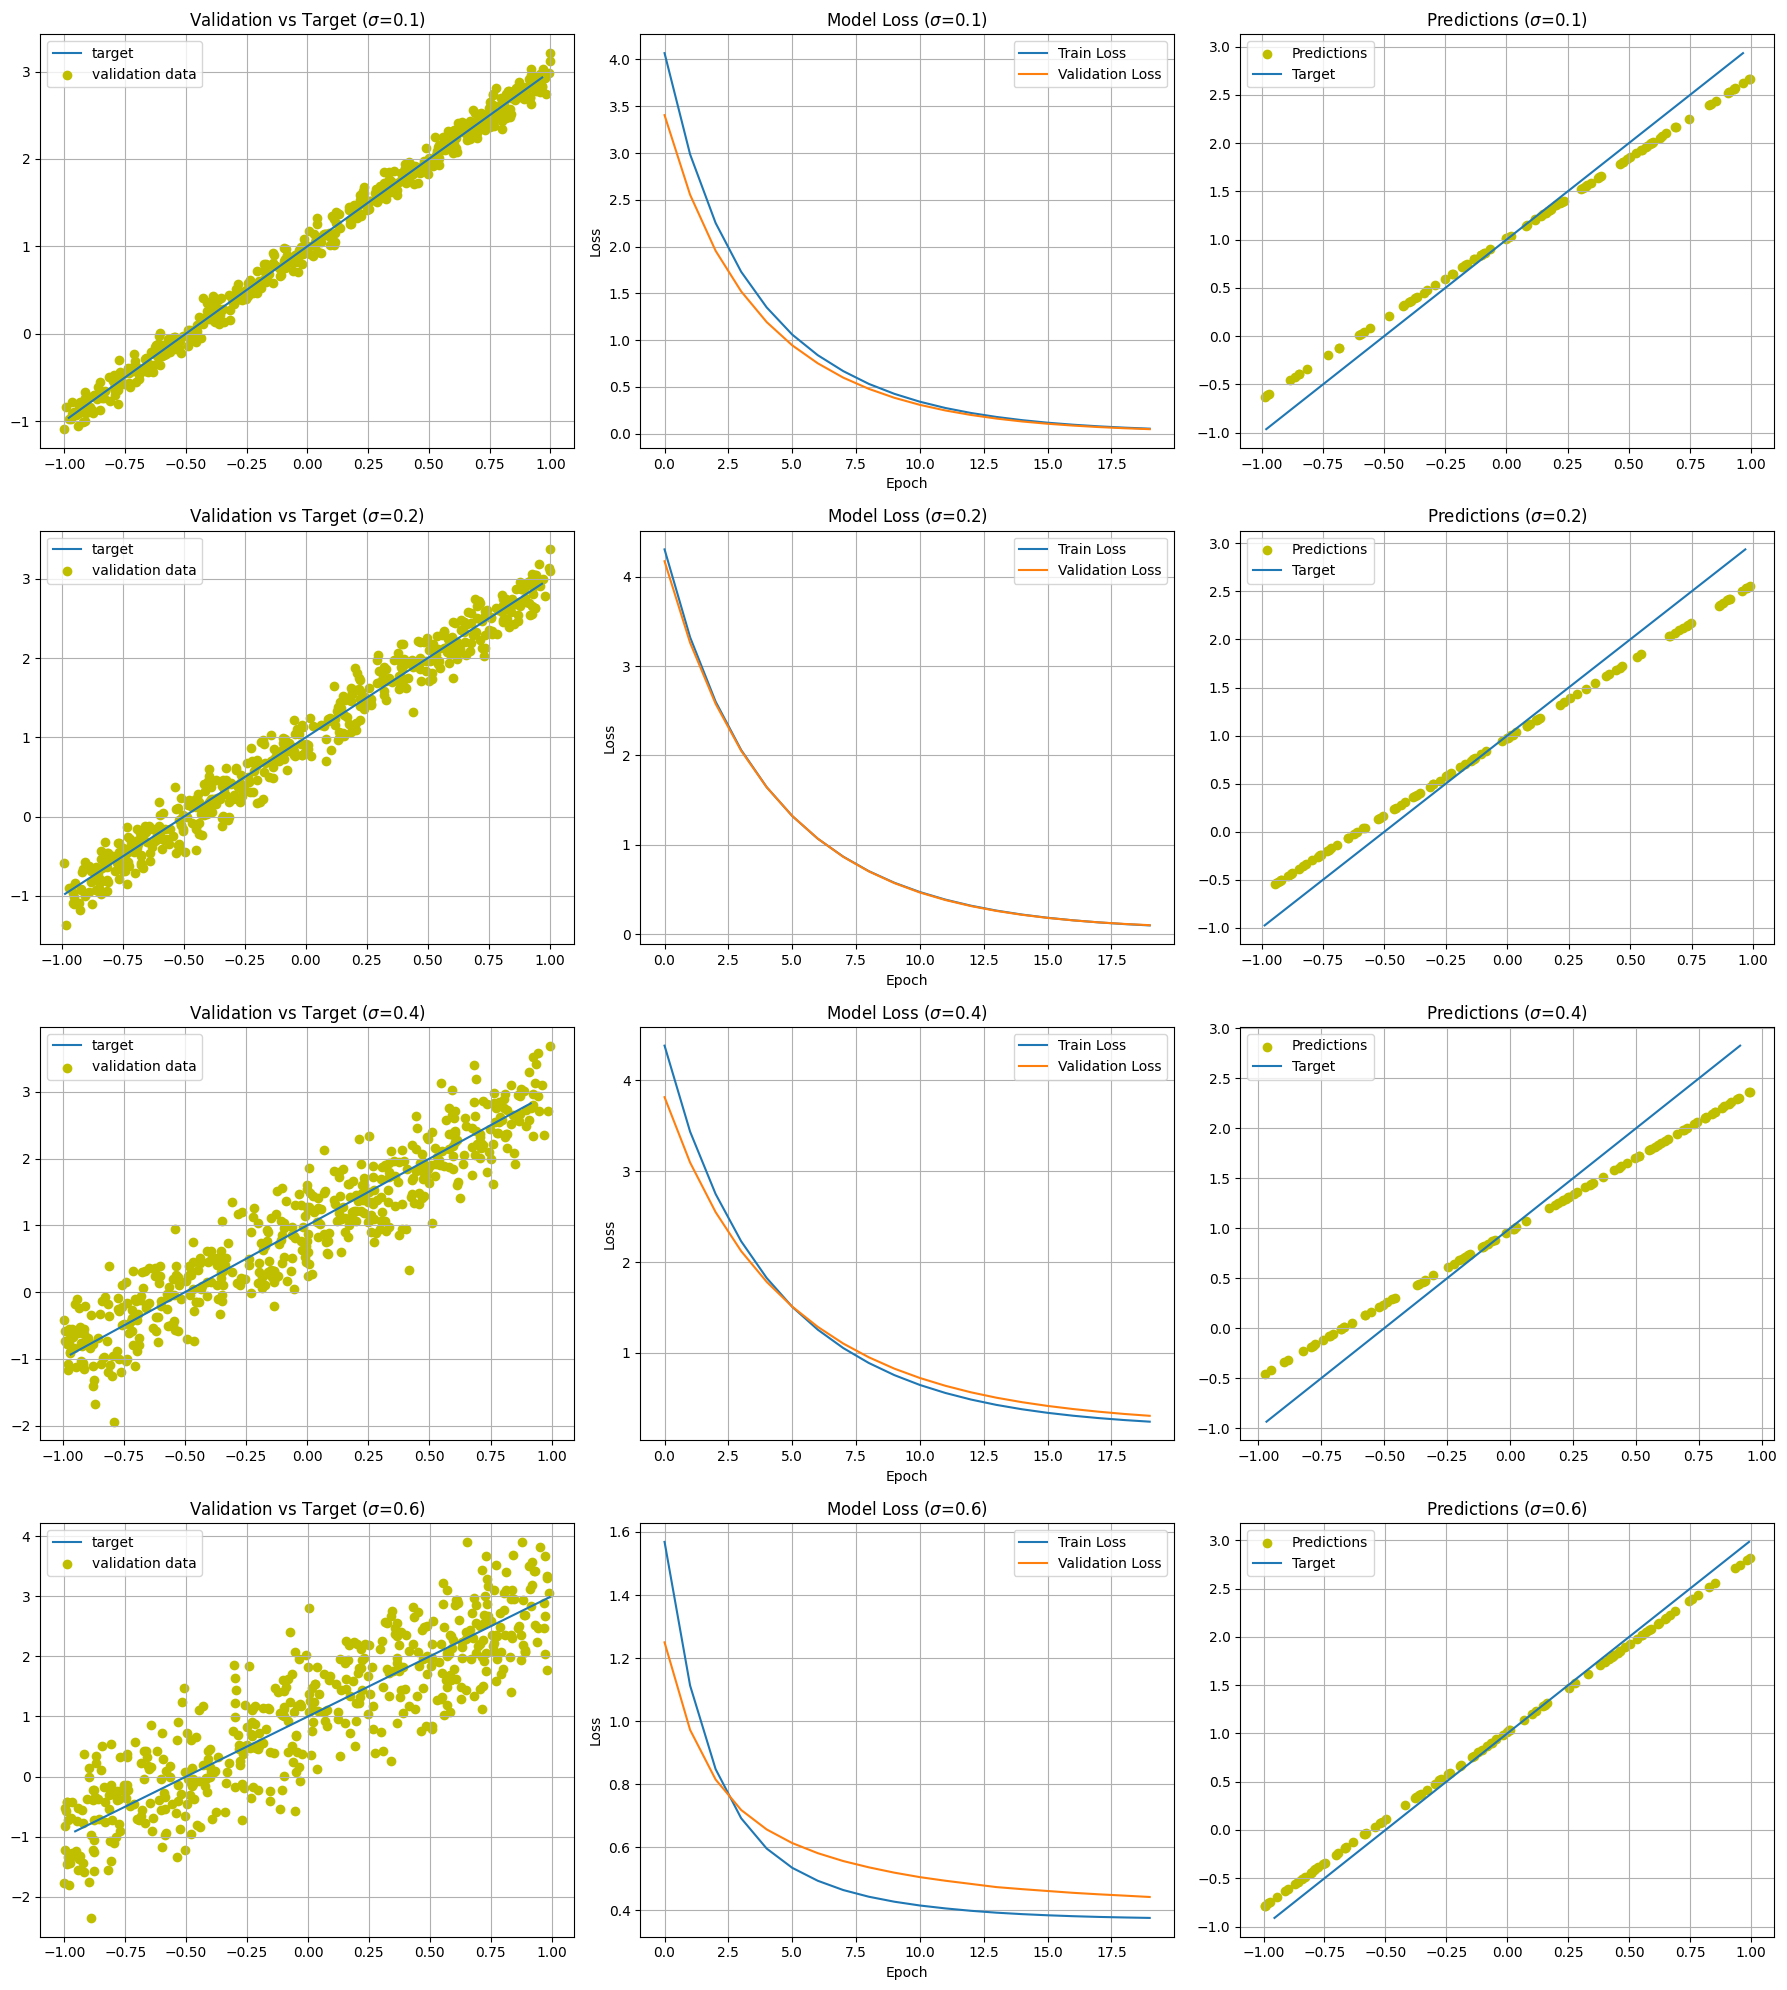

In [ ]:


sigmas = [0.1, 0.2, 0.4, 0.6]
num_sigmas = len(sigmas)

fig, axes = plt.subplots(num_sigmas, 3, figsize=(18, 5 * num_sigmas))


for i, sigma in enumerate(sigmas):
    print(f"--- Model with sigma = {sigma} ---")
    # Dati di base (le x non cambiano a seconda del rumore)
    x_train = np.random.uniform(-1, 1, 500)
    x_valid = np.random.uniform(-1, 1, 50)
    x_valid.sort()
    y_target = m * x_valid + b 
    
    y_train = np.random.normal(m * x_train + b, sigma) 
    y_valid = np.random.normal(m * x_valid + b, sigma)
    
    # 1. CREAZIONE MODELLO (Da fare DENTRO il ciclo per resettare i pesi ogni volta)
    model = tf.keras.Sequential()
    model.add(Dense(1, input_shape=(1,))) 
    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])
    
    # 2. ADDESTRAMENTO
    # verbose=0 nasconde l'output riga per riga per non intasare lo schermo
    history = model.fit(x=x_train, y=y_train, 
                        batch_size=32, epochs=20,
                        shuffle=True, 
                        validation_data=(x_valid, y_valid),
                        verbose=0) 
    
    # 3. VALUTAZIONE
    score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)
    score_target = model.evaluate(x_valid, y_target, batch_size=32, verbose=0)
    print(f"Test loss (vs validation): {score[0]:.4f}")
    print(f"Test loss (vs target exact): {score_target[0]:.4f}\n")
    
    # 4. GRAFICI
    
    # 1° plot: Validation vs Target
    axes[i, 0].plot(x_valid, y_target, label='target')
    axes[i, 0].scatter(x_train, y_train, color='y', label='validation data')
    axes[i, 0].legend()
    axes[i, 0].grid(True)
    axes[i, 0].set_title(f'Validation vs Target ($\sigma$={sigma})')
    
    # 2° plot: Model Loss
    axes[i, 1].plot(history.history['loss'], label='Train Loss')
    axes[i, 1].plot(history.history['val_loss'], label='Validation Loss')
    axes[i, 1].set_title(f'Model Loss ($\sigma$={sigma})')
    axes[i, 1].set_ylabel('Loss')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].legend(loc='best')
    axes[i, 1].grid(True)
    
    # 3° plot: Predictions
    x_predicted = np.random.uniform(-1, 1, 100)
    y_predicted = model.predict(x_predicted, verbose=0)
    
    axes[i, 2].scatter(x_predicted, y_predicted, color='y', label='Predictions')
    axes[i, 2].plot(x_valid, y_target, label='Target')
    axes[i, 2].grid(True)
    axes[i, 2].legend()
    axes[i, 2].set_title(f'Predictions ($\sigma$={sigma})')

# Ottimizza gli spazi e mostra tutto
plt.tight_layout()
plt.savefig('IMAGES/exercise_11_plots_multiple_sigma1.png') # Decommenta per salvare
plt.show()

--- Model with N_train = 70 ---
Test loss (vs validation): 1.2732
Test loss (vs target exact): 1.1891

--- Model with N_train = 100 ---
Test loss (vs validation): 0.3871
Test loss (vs target exact): 0.3766

--- Model with N_train = 200 ---
Test loss (vs validation): 0.0965
Test loss (vs target exact): 0.0492

--- Model with N_train = 1000 ---
Test loss (vs validation): 0.0482
Test loss (vs target exact): 0.0000



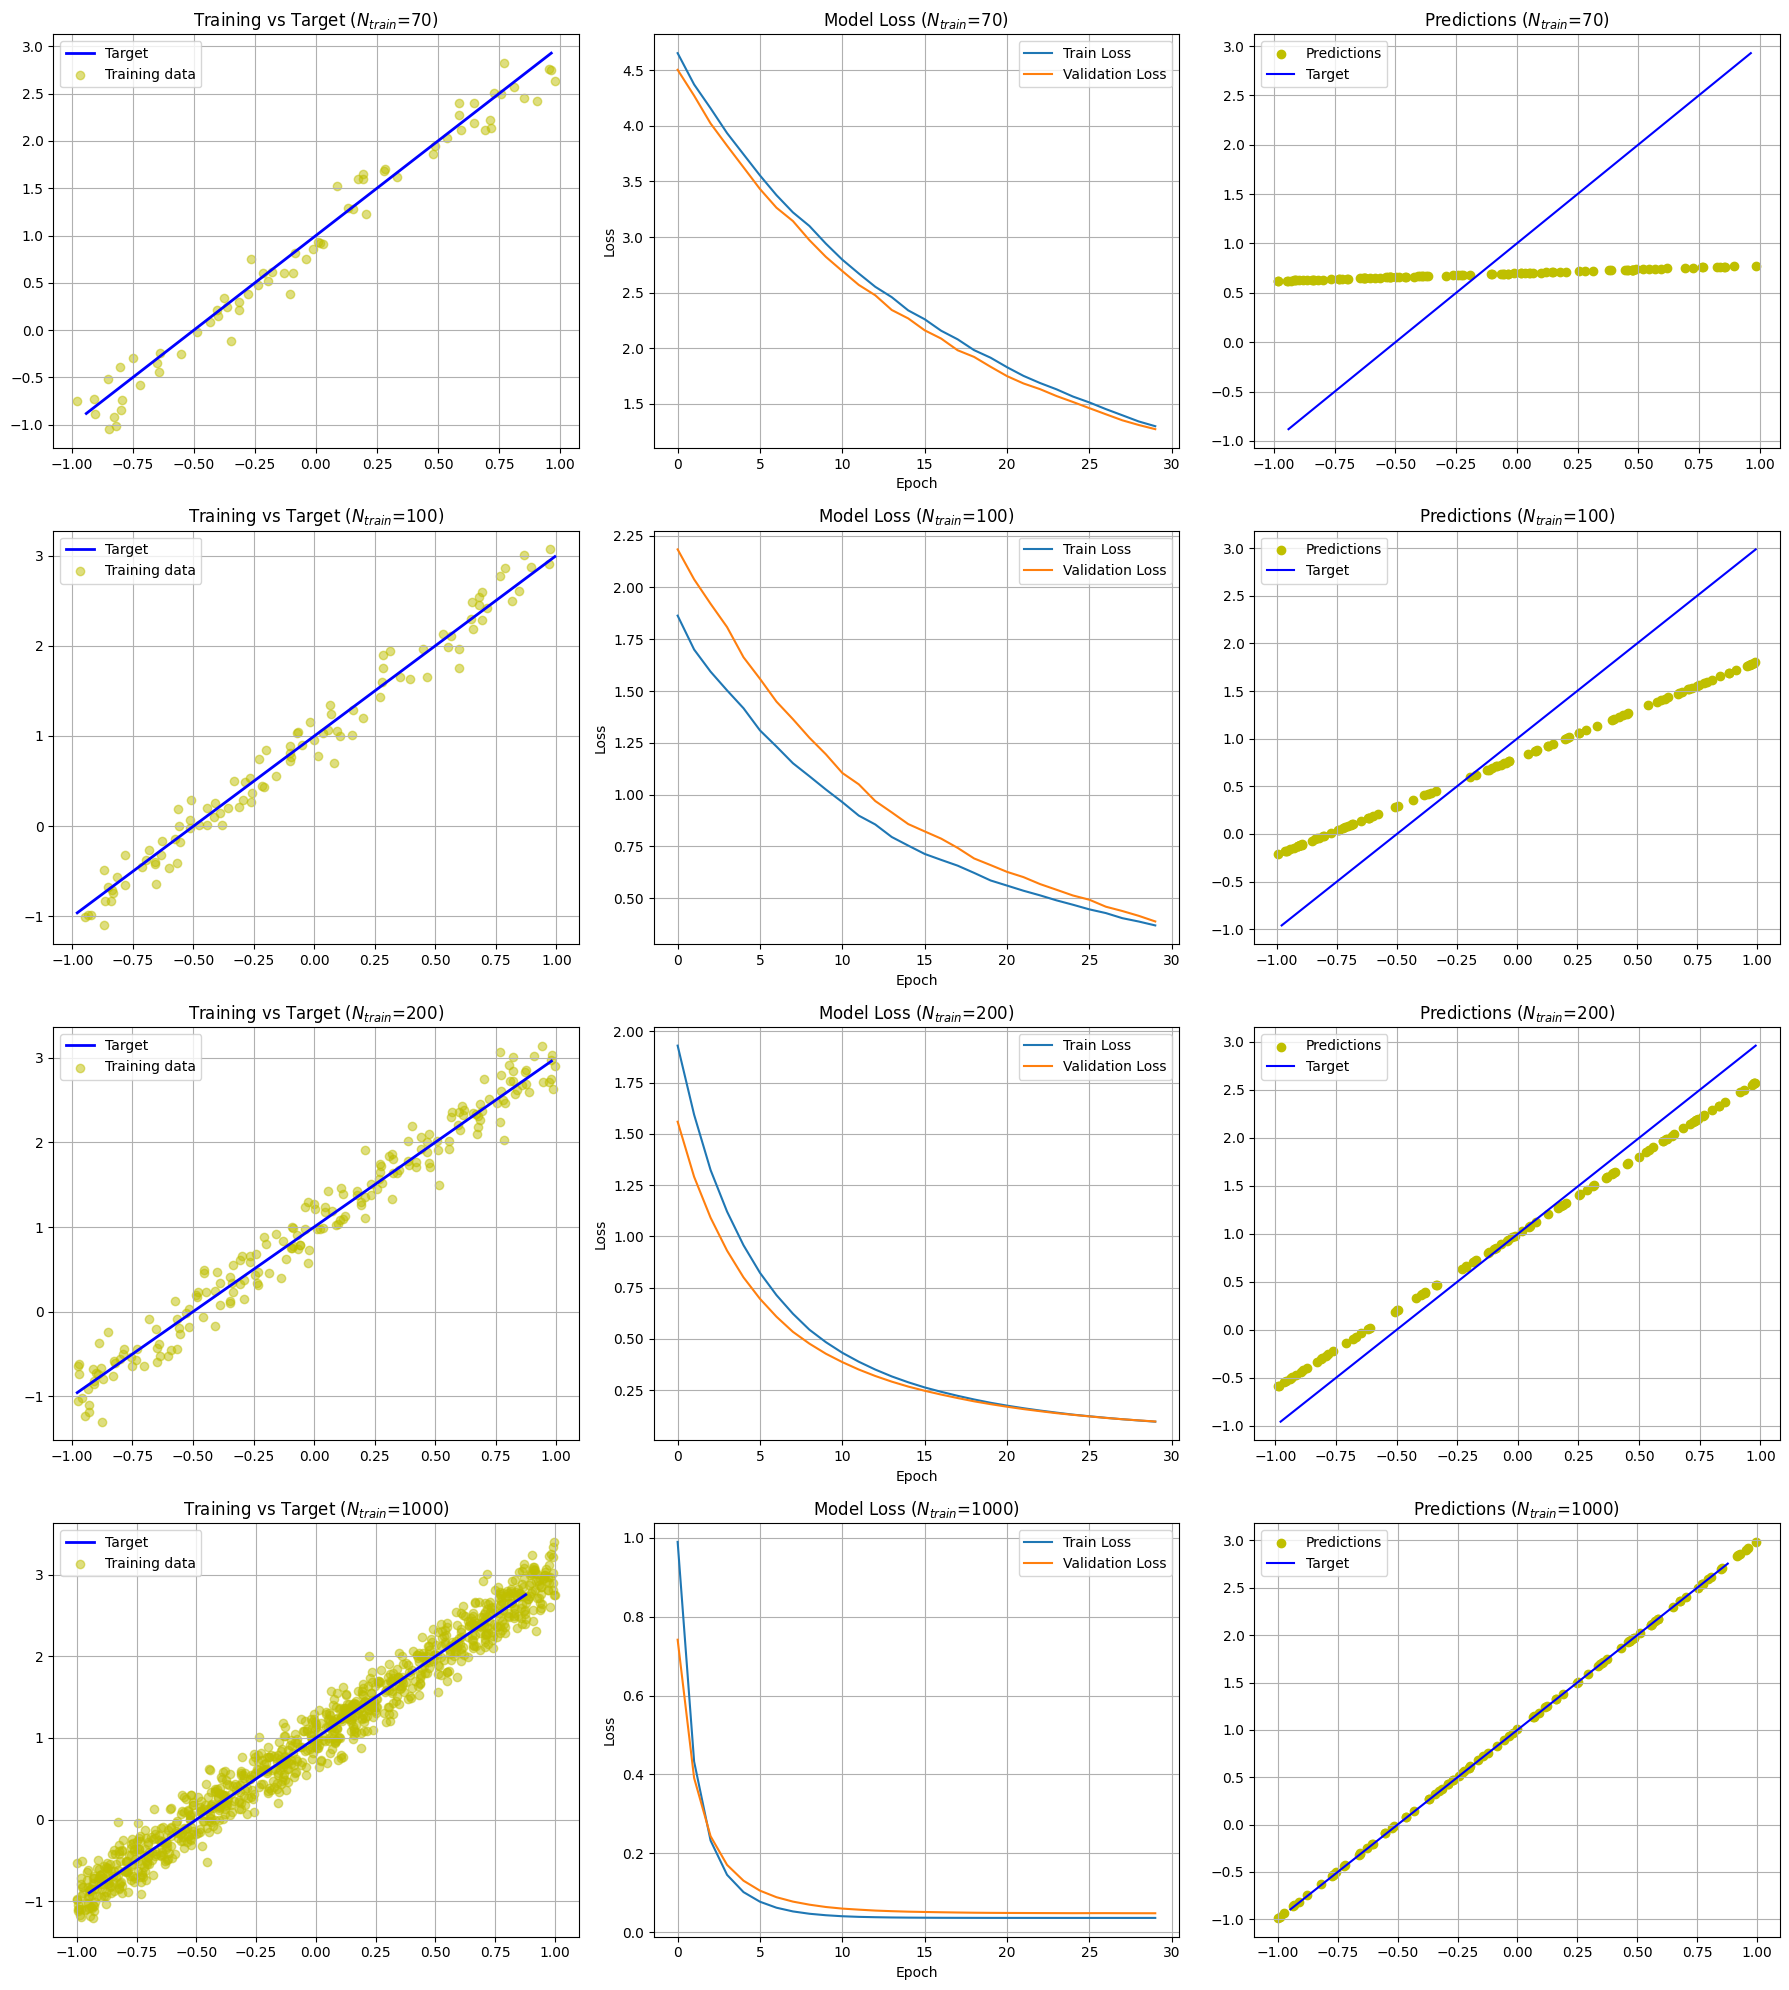

In [ ]:


training = [70, 100, 200, 1000]
sigma = 0.2
num_sigmas = len(training)

fig, axes = plt.subplots(num_sigmas, 3, figsize=(18, 5 * num_sigmas))

for i, training in enumerate(training):
    print(f"--- Model with N_train = {training} ---")
    # Dati di base (le x non cambiano a seconda del rumore)
    x_train = np.random.uniform(-1, 1, training)
    x_valid = np.random.uniform(-1, 1, 50)
    x_valid.sort()
    y_target = m * x_valid + b 
    
    y_train = np.random.normal(m * x_train + b, sigma) 
    y_valid = np.random.normal(m * x_valid + b, sigma)
    
    # 1. CREAZIONE MODELLO (Da fare DENTRO il ciclo per resettare i pesi ogni volta)
    model = tf.keras.Sequential()
    model.add(Dense(1, input_shape=(1,))) 
    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])
    
    # 2. ADDESTRAMENTO
    # verbose=0 nasconde l'output riga per riga per non intasare lo schermo
    history = model.fit(x=x_train, y=y_train, 
                        batch_size=32, epochs=30,
                        shuffle=True, 
                        validation_data=(x_valid, y_valid),
                        verbose=0) 
    
    # 3. VALUTAZIONE
    score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)
    score_target = model.evaluate(x_valid, y_target, batch_size=32, verbose=0)
    print(f"Test loss (vs validation): {score[0]:.4f}")
    print(f"Test loss (vs target exact): {score_target[0]:.4f}\n")
    
    axes[i, 0].plot(x_valid, y_target, label='Target', color='blue', linewidth=2) 
    axes[i, 0].scatter(x_train, y_train, color='y', label='Training data', alpha=0.5)
    axes[i, 0].legend()
    axes[i, 0].grid(True)
    axes[i, 0].set_title(rf'Training vs Target ($N_{{train}}$={training})')
    
    # 2° plot: Model Loss
    axes[i, 1].plot(history.history['loss'], label='Train Loss')
    axes[i, 1].plot(history.history['val_loss'], label='Validation Loss')
    axes[i, 1].set_title(rf'Model Loss ($N_{{train}}$={training})')
    axes[i, 1].set_ylabel('Loss')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].legend(loc='best')
    axes[i, 1].grid(True)
    
    # 3° plot: Predictions
    x_predicted = np.random.uniform(-1, 1, 100)
    y_predicted = model.predict(x_predicted, verbose=0)
    
    axes[i, 2].scatter(x_predicted, y_predicted, color='y', label='Predictions')
    axes[i, 2].plot(x_valid, y_target, label='Target', color='blue')
    axes[i, 2].grid(True)
    axes[i, 2].legend()
    axes[i, 2].set_title(rf'Predictions ($N_{{train}}$={training})')

# Ottimizza gli spazi e mostra tutto
plt.tight_layout()
plt.savefig('IMAGES/exercise_11_plots_multiple_sigma2.png') # Decommenta per salvare
plt.show()

It is possible to see that the $\sigma$ increases (noise level) the errors $E_{in}$ and $E_{out}$ both increase, leading to having a greater $\textit{bias}$. Furthermore, with greater noise the fit proves to be less accurate, this is shown in the third plot on the right where the model tries to predict $y$ values based on it's final parameters and these are compared to the expect $y$ values. 
Two other interesting things to notice are:
- that in the second plot I $N_{epoch} = 30$ instead of $20$ (which I used for the first plot) this means that I gave more opportunities for the model to learn from it's data. 
- the goodness of the regression heavily depends on how much training data I give it, this is clearly seen in the second plot

So it is important to adjust the number of training data, epochs and sigma according to the predictions and the model loss that these parameters yield.

### **Exercise 11.2**

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Find good (& reasonable) choices for:

- the number of layers
- the number of neurons in each layer

- the activation function
- the optimizer
- the loss function
  
Check your NN model by seeing how well your fits predict newly generated test data (including on data outside the range you fit. How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set? 
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.

To understand the what the parameters indicate in the code I write the function in the following way:

$$
f(x)=a-bx-cx^2+dx^3
$$

To verify what is the optimal combination of parameter we perform a $\textbf{grid search}$ of possilbe number of layers, neurons, optimizer function, optimization function and cost function. I saved in a list the characteristic and the value of the lost function in the last epoch for each combination of parameters. 
To easily execute this process I used:
- `itertools`, which is a python library that I used to create `combinations` that calculated the tensor product of all the different vectors of parameters. This guaranteed me to create only 1 `for` cycle instead of 5 that ran over all the elements given by the tensor products.
- `tqdm` to keep track of the progress of the for cycle over all combinations

In [106]:

import itertools
from tqdm import tqdm


def f(x):
    return 4 - 3*x - 2*x**2 + 3*x**3

x_train = np.random.uniform(-1.0, 1.0, 500) +np.random.uniform(0,0.2,500)
x_test = np.random.uniform(-1.0, 1.0, 50)

x_train = np.sort(x_train + np.random.normal(0, 0.2, x_train.shape))
x_test = np.sort(x_test)

y_train = f(x_train)
y_test = f(x_test)

# Keras expects a 2D array of shape (n_samples, 1) for a single feature
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

layer_options = [1, 2, 3]
neurons_options = [4, 8, 16]
activation_options = ['relu', 'tanh', 'sigmoid', 'linear'] 
optimizer_options = ['adam', 'sgd', 'rmsprop']
loss_options = ['mse', 'mae']

results = []

combinations = list(itertools.product(
    layer_options, neurons_options, activation_options, optimizer_options, loss_options
))

for n_layers, n_neurons, activation, optimizer, loss in tqdm(combinations, desc=" ------ GRID SEARCH LOADING..."):
    model = tf.keras.Sequential()
    
    model.add(Dense(n_neurons, activation=activation, input_shape=(1,)))
    
    for _ in range(n_layers - 1):
        model.add(Dense(n_neurons, activation=activation))
        
    model.add(Dense(1))
    
    model.compile(optimizer=optimizer, loss=loss, metrics=['mse'])

    # Allena il modello
    history = model.fit(
        x_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(x_test, y_test),
        verbose=0
    )
    
    # Valuta su validation
    val_loss = history.history['val_loss'][-1]
    
    results.append({
        'layers': n_layers,
        'neurons': n_neurons,
        'activation': activation,
        'optimizer': optimizer,
        'loss': loss,
        'val_loss': val_loss
    })

 ------ GRID SEARCH LOADING...:   0%|          | 0/216 [00:00<?, ?it/s]/Users/carlagariboldi/Documents/MARTINO/UNIMI/III anno/Labo_SimulazioneNumerica/es_11/tf-env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
 ------ GRID SEARCH LOADING...: 100%|██████████| 216/216 [07:33<00:00,  2.10s/it]


Here I created the list containing the parameters relative to the value found for the loss function in the last epoch. So now it is necessary analyse the 10 characteristics with lowest values of the cost function $C(Y, f(X,p))$. The values of the entire library are saved in `results_gridsearch.csv`.

In [108]:

!pip install pandas
import pandas as pd

df_results = pd.DataFrame(results)
df_sorted = df_results.sort_values(by='val_loss', ascending=True)

file_name = 'results_gridsearch.csv'

df_sorted.to_csv(file_name, index=False)
print(f"Results of library saved in: {file_name}")

print(df_sorted.head(10))



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Results of library saved in: results_gridsearch.csv
     layers  neurons activation optimizer loss  val_loss
192       3       16       relu      adam  mse  0.020559
196       3       16       relu   rmsprop  mse  0.022193
193       3       16       relu      adam  mae  0.024089
202       3       16       tanh   rmsprop  mse  0.025243
122       2       16       relu       sgd  mse  0.032098
176       3        8       tanh       sgd  mse  0.032944
198       3       16       tanh      adam  mse  0.034607
104       2        8       tanh       sgd  mse  0.034832
194       3       16       relu       sgd  mse  0.037852
152       3        4       tanh       sgd  mse  0.037911


### 🏆 Top 10 Best Models

| Rank | Layers | Neurons | Activation | Optimizer | Loss | Validation Loss |
|:---:|:---:|:---:|:---|:---|:---:|:---|
| 1 | 3 | 16 | `relu` | `adam` | `mse` | **0.020559** |
| 2 | 3 | 16 | `relu` | `rmsprop` | `mse` | **0.022193** |
| 3 | 3 | 16 | `relu` | `adam` | `mae` | **0.024089** |
| 4 | 3 | 16 | `tanh` | `rmsprop` | `mse` | **0.025243** |
| 5 | 2 | 16 | `relu` | `sgd` | `mse` | **0.032098** |
| 6 | 3 | 8 | `tanh` | `sgd` | `mse` | **0.032944** |
| 7 | 3 | 16 | `tanh` | `adam` | `mse` | **0.034607** |
| 8 | 2 | 8 | `tanh` | `sgd` | `mse` | **0.034832** |
| 9 | 3 | 16 | `relu` | `sgd` | `mse` | **0.037852** |
| 10 | 3 | 4 | `tanh` | `sgd` | `mse` | **0.037911** |

From this analysis we found the 10 superior configurations, however we wish to understand if the change of parameters in fact influences average (the average is calculated over all the other fixed parameters) value of the loss function

However we wish to verify if there is an activation function that proves to be superior respect to others over the use of different layers and neurons and maybe if there is a substantial change over the values of the loss function found with the use of different number of layers and neurons. The most sensible way is showing the average value of the loss function for the different activation functions at a fixed number of layers (and doing it for the 3 different number of layers used). After having done this for the different number of layers it is possible to do this also for the different number of neurons. 

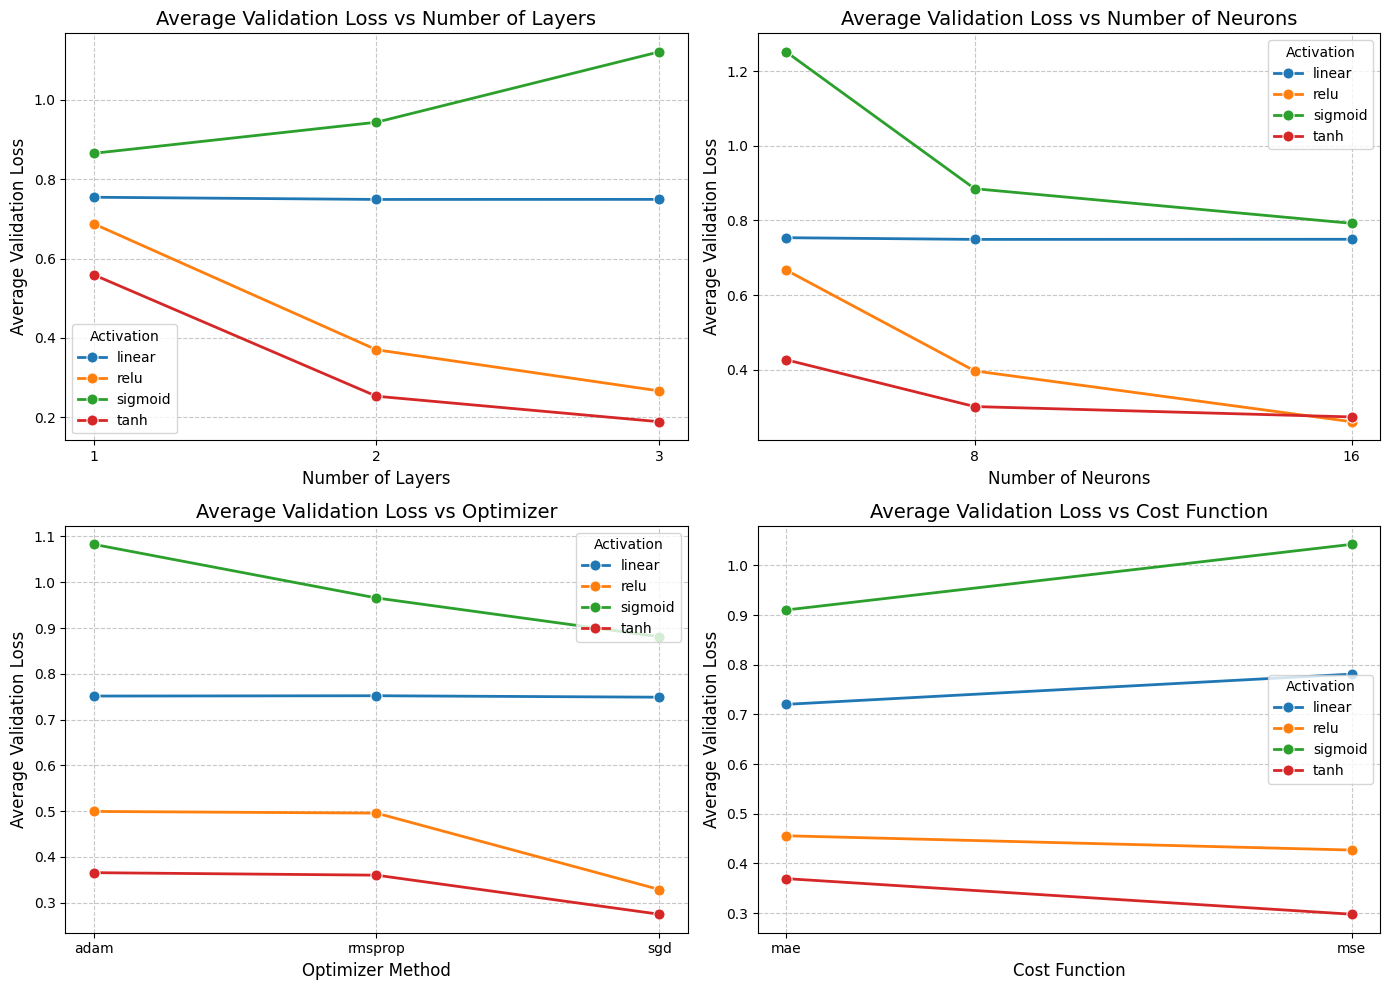

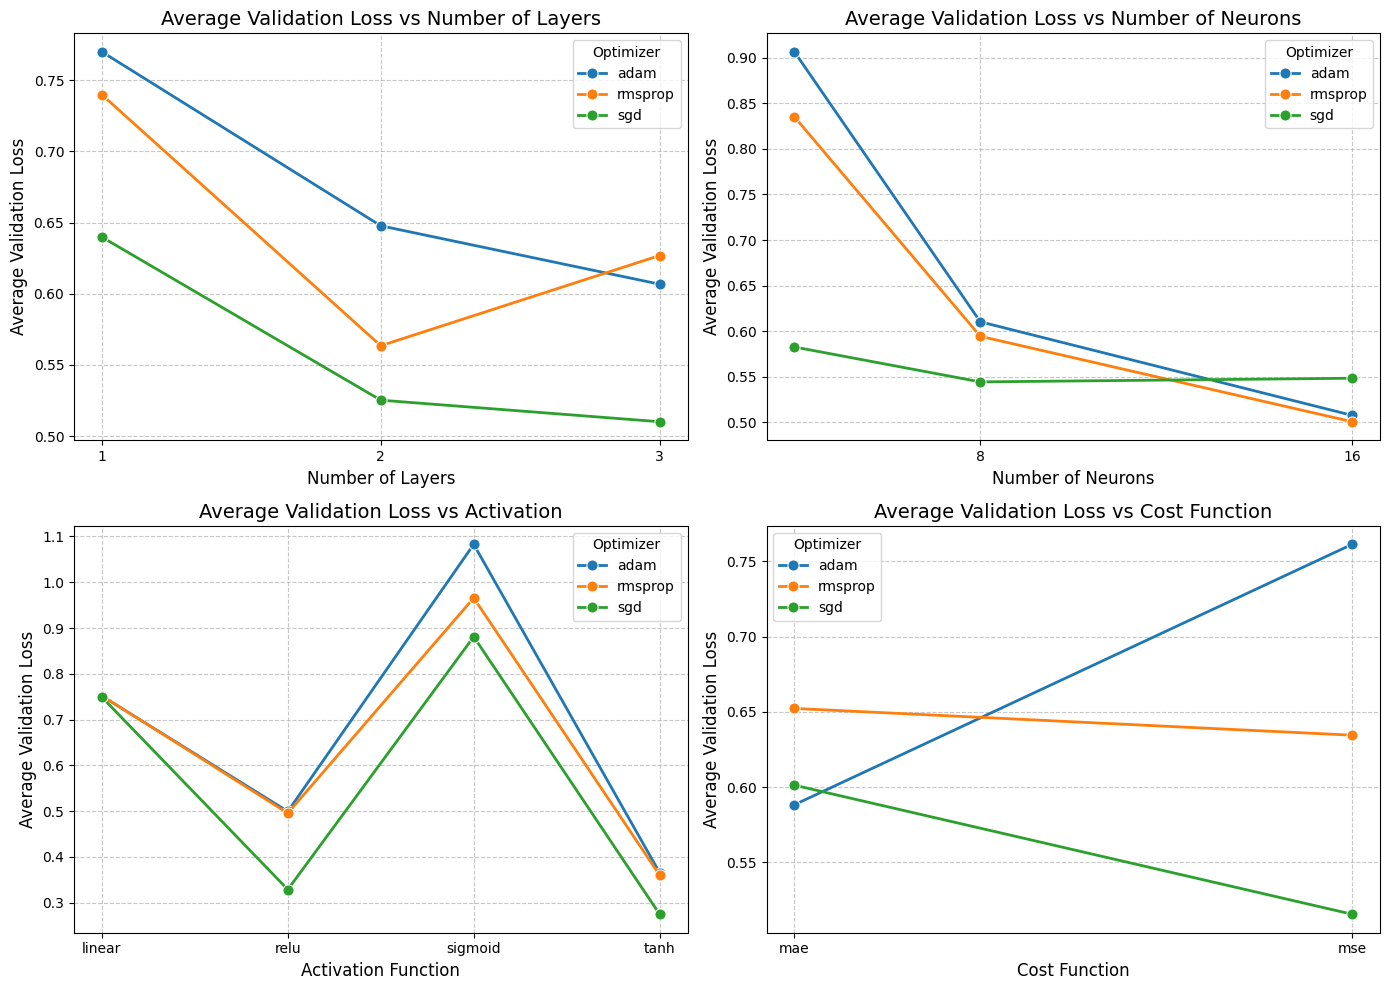

In [109]:
import seaborn as sns

avg_by_layers = df_results.groupby(['layers', 'activation'])['val_loss'].mean().reset_index()
avg_by_neurons = df_results.groupby(['neurons', 'activation'])['val_loss'].mean().reset_index()
avg_by_method = df_results.groupby(['optimizer', 'activation'])['val_loss'].mean().reset_index()
avg_by_cost = df_results.groupby(['loss', 'activation'])['val_loss'].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --------------------------------------------------
# 1° PLOT: Layers (Alto a sinistra)
# --------------------------------------------------
sns.lineplot(
    ax=axes[0,0],        
    data=avg_by_layers, 
    x='layers', 
    y='val_loss', 
    hue='activation',   
    marker='o',         
    linewidth=2,        
    markersize=8        
)
axes[0, 0].set_title('Average Validation Loss vs Number of Layers', fontsize=14)
axes[0, 0].set_xlabel('Number of Layers', fontsize=12)
axes[0, 0].set_ylabel('Average Validation Loss', fontsize=12)
axes[0, 0].set_xticks([1, 2, 3])
axes[0, 0].grid(True, linestyle='--', alpha=0.7)
axes[0, 0].legend(title='Activation', loc='best')

# --------------------------------------------------
# 2° PLOT: Neurons (Alto a destra)
# --------------------------------------------------
sns.lineplot(
    ax=axes[0,1],         
    data=avg_by_neurons, 
    x='neurons', 
    y='val_loss', 
    hue='activation',   
    marker='o',         
    linewidth=2,        
    markersize=8        
)
axes[0,1].set_title('Average Validation Loss vs Number of Neurons', fontsize=14)
axes[0,1].set_xlabel('Number of Neurons', fontsize=12)
axes[0,1].set_ylabel('Average Validation Loss', fontsize=12)
axes[0,1].set_xticks([8, 16]) 
axes[0,1].grid(True, linestyle='--', alpha=0.7)
axes[0,1].legend(title='Activation', loc='best')

# --------------------------------------------------
# 3° PLOT: Optimizer (Basso a sinistra)
# --------------------------------------------------
sns.lineplot(
    ax=axes[1,0],         
    data=avg_by_method, 
    x='optimizer',        
    y='val_loss', 
    hue='activation',   
    marker='o',         
    linewidth=2,        
    markersize=8        
)
axes[1,0].set_title('Average Validation Loss vs Optimizer', fontsize=14)
axes[1,0].set_xlabel('Optimizer Method', fontsize=12) # Sistemata etichetta
axes[1,0].set_ylabel('Average Validation Loss', fontsize=12)
axes[1,0].grid(True, linestyle='--', alpha=0.7)
axes[1,0].legend(title='Activation', loc='best')

# --------------------------------------------------
# 4° PLOT: Loss Function (Basso a destra)
# --------------------------------------------------
sns.lineplot(
    ax=axes[1,1],         
    data=avg_by_cost, 
    x='loss',             
    y='val_loss', 
    hue='activation',   
    marker='o',         
    linewidth=2,        
    markersize=8        
)
axes[1,1].set_title('Average Validation Loss vs Cost Function', fontsize=14)
axes[1,1].set_xlabel('Cost Function', fontsize=12) # Sistemata etichetta
axes[1,1].set_ylabel('Average Validation Loss', fontsize=12)
axes[1,1].grid(True, linestyle='--', alpha=0.7)
axes[1,1].legend(title='Activation', loc='best')

# Ottimizza gli spazi ed esegue il render
plt.tight_layout()
plt.show()

# Calcolo delle medie raggruppate per ottimizzatore
avg_by_layers = df_results.groupby(['layers', 'optimizer'])['val_loss'].mean().reset_index()
avg_by_neurons = df_results.groupby(['neurons', 'optimizer'])['val_loss'].mean().reset_index()
avg_by_method = df_results.groupby(['activation', 'optimizer'])['val_loss'].mean().reset_index()
avg_by_cost = df_results.groupby(['loss', 'optimizer'])['val_loss'].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --------------------------------------------------
# 1° PLOT: Layers (Alto a sinistra)
# --------------------------------------------------
sns.lineplot(
    ax=axes[0,0],        
    data=avg_by_layers, 
    x='layers', 
    y='val_loss', 
    hue='optimizer',   
    marker='o',         
    linewidth=2,        
    markersize=8        
)
axes[0, 0].set_title('Average Validation Loss vs Number of Layers', fontsize=14)
axes[0, 0].set_xlabel('Number of Layers', fontsize=12)
axes[0, 0].set_ylabel('Average Validation Loss', fontsize=12)
axes[0, 0].set_xticks([1, 2, 3])
axes[0, 0].grid(True, linestyle='--', alpha=0.7)
axes[0, 0].legend(title='Optimizer', loc='best')

# --------------------------------------------------
# 2° PLOT: Neurons (Alto a destra)
# --------------------------------------------------
sns.lineplot(
    ax=axes[0,1],         
    data=avg_by_neurons, 
    x='neurons', 
    y='val_loss', 
    hue='optimizer',   
    marker='o',         
    linewidth=2,        
    markersize=8        
)
axes[0,1].set_title('Average Validation Loss vs Number of Neurons', fontsize=14)
axes[0,1].set_xlabel('Number of Neurons', fontsize=12)
axes[0,1].set_ylabel('Average Validation Loss', fontsize=12)
axes[0,1].set_xticks([8, 16])
axes[0,1].grid(True, linestyle='--', alpha=0.7)
axes[0,1].legend(title='Optimizer', loc='best')

# --------------------------------------------------
# 3° PLOT: Activation vs Optimizer (Basso a sinistra)
# --------------------------------------------------
sns.lineplot(
    ax=axes[1,0],         
    data=avg_by_method, 
    x='activation',       
    y='val_loss', 
    hue='optimizer',      
    marker='o',         
    linewidth=2,        
    markersize=8        
)
axes[1,0].set_title('Average Validation Loss vs Activation', fontsize=14) 
axes[1,0].set_xlabel('Activation Function', fontsize=12)                 
axes[1,0].set_ylabel('Average Validation Loss', fontsize=12)
axes[1,0].grid(True, linestyle='--', alpha=0.7)
axes[1,0].legend(title='Optimizer', loc='best')

# --------------------------------------------------
# 4° PLOT: Loss Function (Basso a destra)
# --------------------------------------------------
sns.lineplot(
    ax=axes[1,1],         
    data=avg_by_cost, 
    x='loss',             
    y='val_loss', 
    hue='optimizer',   
    marker='o',         
    linewidth=2,        
    markersize=8        
)
axes[1,1].set_title('Average Validation Loss vs Cost Function', fontsize=14)
axes[1,1].set_xlabel('Cost Function', fontsize=12)
axes[1,1].set_ylabel('Average Validation Loss', fontsize=12)
axes[1,1].grid(True, linestyle='--', alpha=0.7)
axes[1,1].legend(title='Optimizer', loc='best')

# Ottimizza gli spazi ed esegue il render
plt.tight_layout()
plt.show()

#### **Take-home messages from the first plots**
- the best $2$ methods are the ones that use as activation function $tanh$ and Relu.
- There is no substantial change between the use of the two different cost functions, so I will continue to use the Mean Squared Loss function. 
- It is favourable to use more neurons in the layers (all activation function are in agreement with these statement)
- The linear activation function is invariant to all parameter changes
- 2 layers seems to be on average between the different activation functions the number of neurons that lowers the activation cost. Only for $tanh$ it is favourable to have 3 layers.


#### **Take-home messages from the second plots**
- there is a great difference between the use of `mse` and `mae` in using different optimizer. The most favourable option is to use `mse` for the Standard Gradient Descent optimization method
- on all other plots SDG and RMSPROP are very close for the greater values of neurons and layers. 
- For all optimization methods the best activation function to use it $tanh$
- It is best to use a great number of neurons for all optimization methods

#### **How well does the NN fit the actual $f(x)$**
To verify this I decided to use the parameters that ranked first overall:
| Layers | Neurons | Activation | Optimizer | Loss | Validation Loss |
|:---:|:---:|:---|:---|:---:|:---|
| 3 | 16 | `relu` | `adam` | `mse` | **0.007546** |

I trained the NN with 2000 values however we can see that it is still not enough to fit also outside the domain. This is due to the fact that the model plots any analitical function, not specifically a polinomial one, so outside the domain the FIT function doesn't follow the trend of the $f(x)$. Increasing the training data set leads to a more precise fit but only in the domain.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


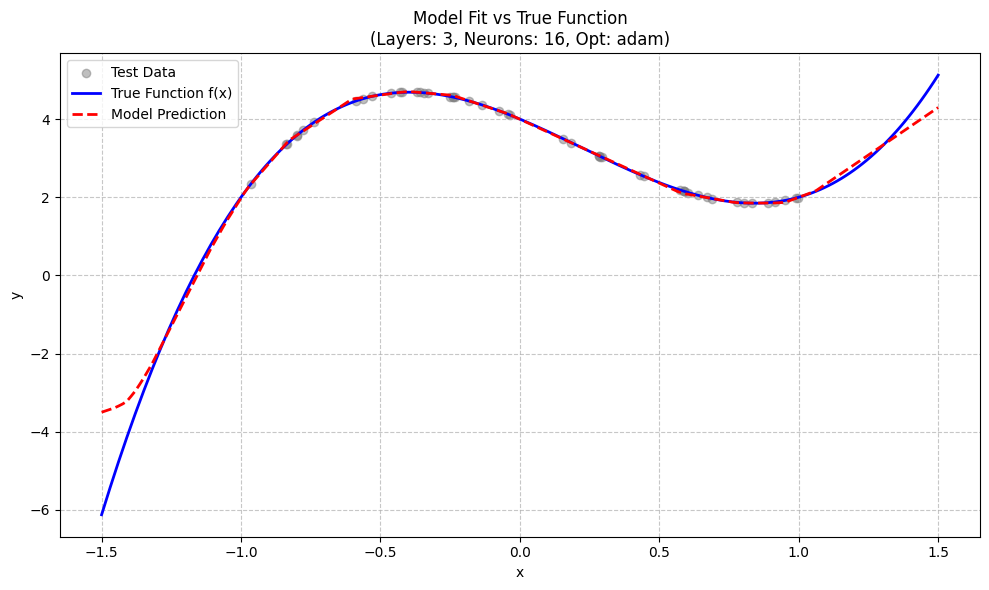

In [124]:
n_neurons = 16
n_layers = 3
activation = 'relu'
optimizer = 'adam'
loss = 'mse'

x_train = np.random.uniform(-1.0, 1.0, 2000) + np.random.normal(0, 0.2, 2000)
x_test = np.random.uniform(-1.0, 1.0, 50)
x_train.sort()
x_test.sort()
y_train = f(x_train)
y_test = f(x_test)

model = tf.keras.Sequential()
model.add(Dense(n_neurons, activation=activation))
for _ in range(n_layers -1):
    model.add(Dense(n_neurons, activation=activation))
model.add(Dense(1))

model.compile(optimizer=optimizer, loss=loss, metrics=['mse'])

# Rimodella i dati da (500,) a (500, 1)
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

# È buona pratica farlo anche per le y
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Ora puoi far partire il fit senza errori!
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test), 
    verbose=0 
)

x_plot = np.linspace(-1.5, 1.5, 200)
y_plot_true = f(x_plot) 
y_plot_pred = model.predict(x_plot)

plt.figure(figsize=(10, 6))

# Plottiamo i dati di test (opzionale, ma utile per vedere su cosa si sta valutando)
plt.scatter(x_test, y_test, color='gray', label='Test Data', alpha=0.5)
plt.plot(x_plot, y_plot_true, color='blue', label='True Function f(x)', linewidth=2)
plt.plot(x_plot, y_plot_pred, color='red', label='Model Prediction', linestyle='--', linewidth=2)

plt.title(f'Model Fit vs True Function\n(Layers: {n_layers}, Neurons: {n_neurons}, Opt: {optimizer})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


However, if we greate a NN in which we provide the model the information that the function that we are trying to fit is a $3^{rd}$-order polynomial then we expect that even the points outside the domain will follow the analytic trend.

/Users/carlagariboldi/Documents/MARTINO/UNIMI/III anno/Labo_SimulazioneNumerica/es_11/tf-env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


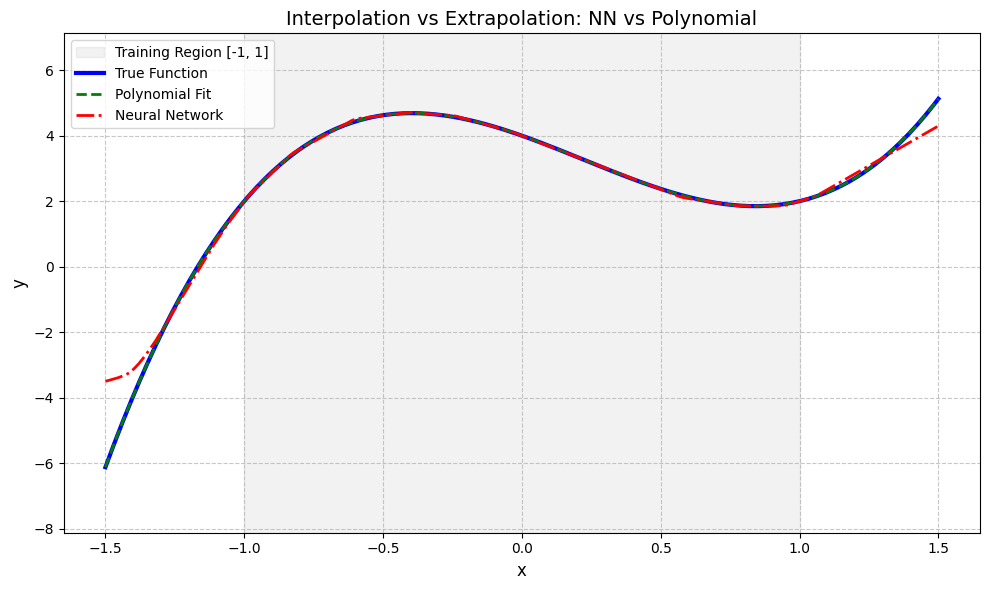

In [125]:
# ==========================================
# 1. RESTRICTED TRAINING SET (Only between -1 and 1)
# ==========================================
x_train = np.random.uniform(-1.0, 1.0, 500) + np.random.normal(0, 0.2, 500)
x_train.reshape(-1,1)
y_train = f(x_train)

# ==========================================
# 2. NEURAL NETWORK CREATION & TRAINING
# ==========================================
model = tf.keras.Sequential([
    Dense(16, activation='relu', input_shape=(1,)),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='rmsprop', loss='mse')
model.fit(x_train, y_train, epochs=50, batch_size=32, verbose=0)

# ==========================================
# 3. POLYNOMIAL FIT ON THE SAME RANGE
# ==========================================
coefficients = np.polyfit(x_train.flatten(), y_train.flatten(), 3)
poly_function = np.poly1d(coefficients)
x_plot = np.linspace(-1.5, 1.5, 200).reshape(-1, 1)
y_plot_true = f(x_plot)

y_plot_nn = model.predict(x_plot)
y_plot_poly = poly_function(x_plot.flatten())

# Plotting
plt.figure(figsize=(10, 6))

# Gray area to show where the network was actually trained
plt.axvspan(-1.0, 1.0, color='gray', alpha=0.1, label='Training Region [-1, 1]')

plt.plot(x_plot, y_plot_true, color='blue', linewidth=3, label='True Function')
plt.plot(x_plot, y_plot_poly, color='green', linestyle='--', linewidth=2, label='Polynomial Fit')
plt.plot(x_plot, y_plot_pred, color='red', linestyle='-.', linewidth=2, label='Neural Network')

plt.title('Interpolation vs Extrapolation: NN vs Polynomial', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)

# Set a limit to the Y-axis because the NN might "explode" with huge values outside the range
plt.ylim(min(y_plot_true)-2, max(y_plot_true)+2) 

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Exercise 11.3
  
Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$. We use the same hyperparameters as before:
| Layers | Neurons | Activation | Optimizer | Loss | Validation Loss |
|:---:|:---:|:---|:---|:---:|:---|
| 3 | 32 | `relu` | `adam` | `mse` | **0.020559** |

But instead of using only 16 problems, since the function to fit is more complex now because the domain is in 2 dimensions, I will use doubled the amount of neurons for each layer. 



In [157]:
def f_sin(x_1,x_2):
    return np.sin(x_1**2 + x_2**2)

N_train = 2000
x_train = np.random.uniform(-1.5, 1.5, (N_train,2)) + np.random.normal(0, 0.2, (N_train,2))

y_train = f_sin(x_train[:,0], x_train[:,1])

N_valid = 50
x_valid = np.random.uniform(-1.5, 1.5, (N_valid, 2)) + np.random.normal(0, 0.2, (N_valid,2))

y_valid = f_sin(x_valid[:, 0], x_valid[:, 1])

modelf_sin = tf.keras.Sequential([
    Dense(32, activation='relu', input_shape=(2,)), 
    Dense(32, activation='relu'),
    Dense(1)
])

modelf_sin.compile(optimizer='nadam', loss='mse', metrics=['mse'])
history_2d = modelf_sin.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)





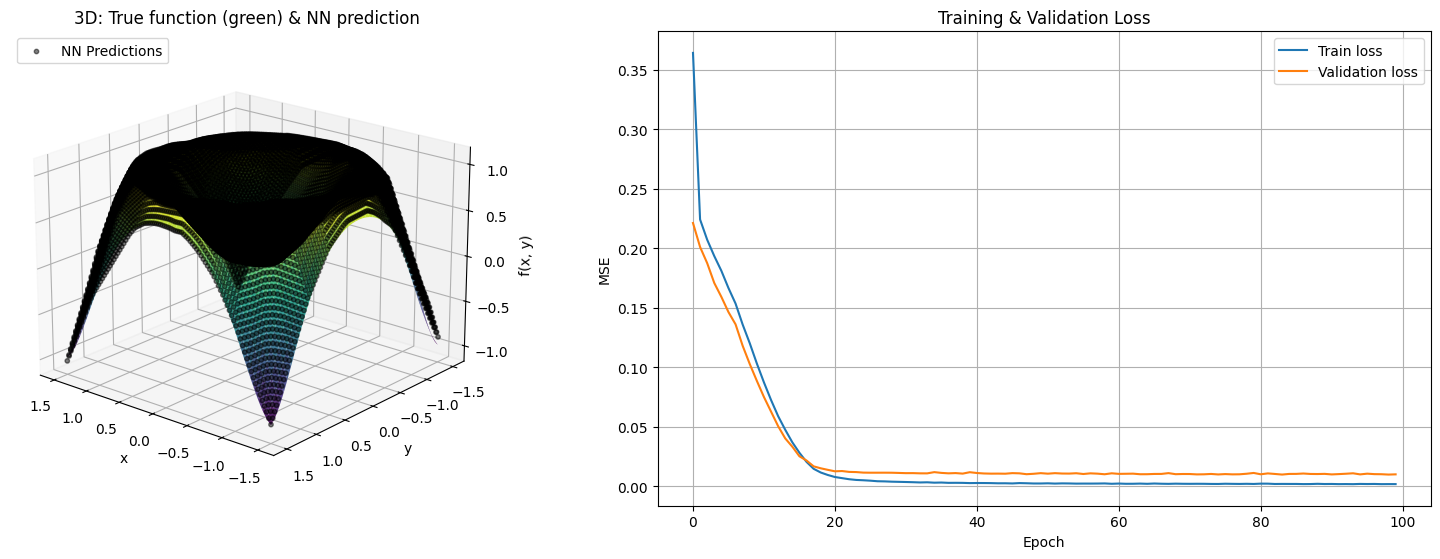

In [159]:
x_grid = np.linspace(-1.5, 1.5, 100)
y_grid = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z_true = f_sin(X, Y)

grid_points = np.column_stack([X.ravel(), Y.ravel()])
Z_pred = modelf_sin.predict(grid_points, verbose=0).reshape(X.shape)

fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z_true, cmap='viridis', alpha=0.9)
# Plot predicted surface
#ax1.plot_surface(X, Y, Z_pred, cmap='autumn', alpha=0.5)
ax1.scatter(grid_points[:, 0], grid_points[:, 1], Z_pred.ravel(), color='k',alpha= 0.5, s=10, label='NN Predictions')
ax1.set_title('3D: True function (green) & NN prediction')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
ax1.legend(loc='upper left')
ax1.view_init(elev=20, azim=130)

# Plot training and validation loss
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(history_2d.history['loss'], label='Train loss')
ax2.plot(history_2d.history['val_loss'], label='Validation loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE')
ax2.set_title('Training & Validation Loss')
ax2.legend(loc ='upper right')
ax2.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])

To do this exercise I worked with $N_{train}=2000$ and with $N_{test} = 50$. We can see that the NN fits well the function 
$$f(x) = \sin(x^2 + y^2)$$

After a great number of epochs, after the model has had the correct amount of training we find that the $E_{in} \leq E_{out}$ as expected. 